In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

# Try project imports first.
# If your package is installed / notebook is run from project root, these should work directly.
from agentic_energy.schemas import BatteryParams, DayInputs, SolveRequest, SolveResponse
from agentic_energy.milp.milp_mcp_server import records_to_arrays, solve_daily_milp
from agentic_energy.milp.robust_baselines import (
    estimate_bias, apply_bias, residual_matrix, sample_scenarios, 
    solve_bias_corrected_deterministic,
    solve_scenario_expected_cost,
    solve_scenario_cvar 
)  
from agentic_energy.data_loader import EnergyDataLoader, BatteryDataLoader
from agentic_energy.schemas import BatteryParams, DayInputs, EnergyDataRecord, SolveFromRecordsRequest

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


Available LLM providers: ['gemini', 'openai', 'ollama']


In [2]:
REGION="NEWYORK"
YEAR = 2022
data_version = "forecast"
forecast_type = "RF"
duration_hours=4
capacity=43.13
soc_init=0.5
soc_min=0.0
soc_max=1.0
eta_c = 0.95
eta_d = 0.95
soc_target=0.5


history_start_date=f"{YEAR}-01-01"
history_end_date=f"{YEAR}-12-31"
test_start_date=f"{YEAR+1}-01-01"
test_end_date=f"{YEAR+1}-12-31"

CVAR_SEEDS = [0]

# common CVaR confidence levels meaning
#  we optimize for the worst 10%, 5%, or 1% of scenarios
# BETAS = [0.90, 0.95, 0.99] 
BETAS = [0.95]
# risk aversion levels from risk-neutral (0.0) to fully robust (1.0) meaning 
# we weight the CVaR term from 0% to 100% in the objective
# LAMBDAS = [0.0, 0.25, 0.5, 0.75, 1.0]
LAMBDAS = [0.5]
N_SCENARIOS = 100
BLOCK_BOOTSTRAP = True 


# history_start_date="2019-01-01"
# history_end_date="2019-12-31"
# test_start_date="2019-12-01"
# test_end_date="2019-12-01"

In [3]:
history_forecast_obj = EnergyDataLoader(region = REGION, data_version=data_version, forecast_type=forecast_type)
history_forecast_data = history_forecast_obj.load_region_data()
history_forecast = await history_forecast_obj.get_filtered_data(history_start_date, history_end_date)

test_forecast_obj = EnergyDataLoader(region = REGION, data_version=data_version, forecast_type=forecast_type)
test_forecast_data = test_forecast_obj.load_region_data()
test_forecast = await test_forecast_obj.get_filtered_data(test_start_date, test_end_date)

2026-04-15 02:02:02.754 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/NewYork_data_forecast_RF.csv
2026-04-15 02:02:03.136 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/NewYork_data_forecast_RF.csv


In [4]:
history_actual_obj = EnergyDataLoader(region=REGION, data_version = "actual")
history_actual_data = history_actual_obj.load_region_data()
history_actual = await history_actual_obj.get_filtered_data(start_date=history_start_date, end_date=history_end_date)

test_actual_obj = EnergyDataLoader(region=REGION, data_version = "actual")
test_actual_data = test_actual_obj.load_region_data()
test_actual = await test_actual_obj.get_filtered_data(start_date=test_start_date, end_date=test_end_date)

2026-04-15 02:02:03.480 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/NewYork_data_actual.csv
2026-04-15 02:02:03.831 | DEBUG    | agentics.core.agentics:from_csv:307 - Importing Agentics of type EnergyDataRecord from CSV /Users/millendroy/Projects/Agentic_Energy/Agentics_for_EnergyArbitrage_Battery/agentic_energy/agentic_energy/data/NewYork_data_actual.csv


In [5]:
from datetime import datetime, timedelta
stats= await EnergyDataLoader.get_summary_stats_from_ag(history_actual_data)
timedelta = datetime.strptime(stats.states[0].date_range.end, "%Y-%m-%d %H:%M:%S") - datetime.strptime(stats.states[0].date_range.start, "%Y-%m-%d %H:%M:%S")
days = timedelta.days + 1
days

365

In [6]:
def keep_full_days(records):
    """
    Filters the input records to keep only those that belong to full days 
    (i.e., days with 24 hourly records). Returns the filtered records and the list of valid dates.
    """
    rows = [r for r in records if r.prices is not None and r.consumption is not None]
    rows = sorted(rows, key=lambda r: r.timestamps)

    grouped = {}
    for r in rows:
        d = pd.to_datetime(r.timestamps).date()
        grouped.setdefault(d, []).append(r)

    full_day_records = []
    valid_dates = []

    for d in sorted(grouped.keys()):
        day_rows = sorted(grouped[d], key=lambda r: r.timestamps)
        if len(day_rows) == 24:
            full_day_records.extend(day_rows)
            valid_dates.append(d)

    return full_day_records, valid_dates


history_forecast_records, history_dates = keep_full_days(history_forecast.states)
history_actual_records, _ = keep_full_days(history_actual.states)

test_forecast_records, test_dates = keep_full_days(test_forecast.states)
test_actual_records, _ = keep_full_days(test_actual.states)

print(len(history_dates), len(test_dates))
print(len(history_forecast_records), len(history_actual_records))
print(len(test_forecast_records), len(test_actual_records))

364 364
8736 8736
8736 8736


In [7]:
# capacity = 43.13  # MWh
batterydetails = BatteryParams(
    capacity_MWh=capacity,   # 4-hour energy at 100 MW power: good for diurnal spreads
    soc_init=soc_init,        # neutral start
    soc_min=soc_min,         # keep 10% buffer for longevity + contingency
    soc_max=soc_max,         # avoid top-of-charge stress
    cmax_MW=capacity/duration_hours,        # 4-hour duration (capacity/4)
    dmax_MW=capacity/duration_hours,        # symmetric charge/discharge
    eta_c=eta_c,           # ~92% round-trip when paired with eta_d
    eta_d=eta_d,
    soc_target=soc_target       # keep headroom to buy when prices dip; adjust by time-of-day policy
)
# batterydetails = batt.compute_battery_params()
print(batterydetails)

capacity_MWh=43.13 soc_init=0.5 soc_min=0.0 soc_max=1.0 cmax_MW=10.7825 dmax_MW=10.7825 eta_c=0.95 eta_d=0.95 soc_target=0.5


In [8]:
price_actual_hist = []
price_forecast_hist = []
demand_actual_hist = []
demand_forecast_hist = []

for i in range(len(history_forecast_records) // 24):
    forecast_prices, forecast_demand = records_to_arrays(
        history_forecast_records[i*24:(i+1)*24]
    )
    actual_prices, actual_demand = records_to_arrays(
        history_actual_records[i*24:(i+1)*24]
    )

    price_forecast_hist.append(forecast_prices)
    demand_forecast_hist.append(forecast_demand)
    price_actual_hist.append(actual_prices)
    demand_actual_hist.append(actual_demand)

price_actual_hist = np.array(price_actual_hist, dtype=float)
price_forecast_hist = np.array(price_forecast_hist, dtype=float)
demand_actual_hist = np.array(demand_actual_hist, dtype=float)
demand_forecast_hist = np.array(demand_forecast_hist, dtype=float)

print(price_actual_hist.shape)
print(price_forecast_hist.shape)
print(demand_actual_hist.shape)
print(demand_forecast_hist.shape)

(364, 24)
(364, 24)
(364, 24)
(364, 24)


In [9]:
price_bias = estimate_bias(price_actual_hist, price_forecast_hist)
demand_bias = estimate_bias(demand_actual_hist, demand_forecast_hist)

price_residuals = residual_matrix(price_actual_hist, price_forecast_hist, bias_correct=True)
demand_residuals = residual_matrix(demand_actual_hist, demand_forecast_hist, bias_correct=True)

print(price_bias.shape, demand_bias.shape)
print(price_residuals.shape, demand_residuals.shape)

(24,) (24,)
(364, 24) (364, 24)


In [10]:
all_results_cvar = {}
all_day_info_cvar = {}

for beta in BETAS:
    for lam in LAMBDAS:
        for seed in CVAR_SEEDS:
            print(f"\nRunning CVaR MILP | beta={beta} | lambda={lam} | seed={seed}")

            results_cvar = []
            day_info_cvar = []

            n_days = len(test_forecast_records) // 24

            for i in range(n_days):
                print(f"  Solving day {i+1} of {n_days}")

                forecast_prices, forecast_demand = records_to_arrays(
                    test_forecast_records[i*24:(i+1)*24]
                )
                actual_prices, actual_demand = records_to_arrays(
                    test_actual_records[i*24:(i+1)*24]
                )

                forecast_prices = np.asarray(forecast_prices, dtype=float)
                forecast_demand = np.asarray(forecast_demand, dtype=float)
                actual_prices = np.asarray(actual_prices, dtype=float)
                actual_demand = np.asarray(actual_demand, dtype=float)

                # bias-corrected forecast
                price_forecast_corr = apply_bias(forecast_prices, price_bias)
                demand_forecast_corr = apply_bias(forecast_demand, demand_bias)

                # scenarios vary with seed
                price_scenarios = sample_scenarios(
                    base_forecast=price_forecast_corr,
                    residuals=price_residuals,
                    n_scenarios=N_SCENARIOS,
                    random_state=seed + i,
                    block_bootstrap=BLOCK_BOOTSTRAP,
                )

                demand_scenarios = sample_scenarios(
                    base_forecast=demand_forecast_corr,
                    residuals=demand_residuals,
                    n_scenarios=N_SCENARIOS,
                    random_state=seed + 1000 + i,
                    block_bootstrap=BLOCK_BOOTSTRAP,
                )

                res_cvar = solve_scenario_cvar(
                    batt=batterydetails,
                    price_scenarios=price_scenarios,
                    demand_scenarios=demand_scenarios,
                    beta=beta,
                    lam=lam,
                    dt_hours=1.0,
                    prices_sell_scenarios=price_scenarios,
                    solver="GUROBI",
                    solver_opts=None,
                )

                day_cvar = DayInputs(
                    prices_buy=actual_prices.tolist(),
                    demand_MW=actual_demand.tolist(),
                    prices_sell=actual_prices.tolist(),
                    allow_export=True,
                    dt_hours=1.0,
                    prices_buy_forecast=price_forecast_corr.tolist(),
                    demand_MW_forecast=demand_forecast_corr.tolist(),
                    prices_sell_forecast=price_forecast_corr.tolist(),
                )

                results_cvar.append(res_cvar)
                day_info_cvar.append(day_cvar)

            all_results_cvar[(beta, lam, seed)] = results_cvar
            all_day_info_cvar[(beta, lam, seed)] = day_info_cvar


Running CVaR MILP | beta=0.95 | lambda=0.5 | seed=0
  Solving day 1 of 364
Set parameter WLSAccessID


[04/15/26 02:02:10] INFO     Set parameter WLSAccessID                                           ]8;id=913925;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=236266;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\

Set parameter WLSSecret


                    INFO     Set parameter WLSSecret                                             ]8;id=446367;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=221946;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\

Set parameter LicenseID to value 2718037


                    INFO     Set parameter LicenseID to value 2718037                            ]8;id=14891;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=3978;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\

Academic license 2718037 - for non-commercial use only - registered to mi___@columbia.edu


                    INFO     Academic license 2718037 - for non-commercial use only - registered ]8;id=73979;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py\gurobi_qpif.py]8;;\:]8;id=617615;file:///Users/millendroy/anaconda3/envs/agentics/lib/python3.11/site-packages/cvxpy/reductions/solvers/qp_solvers/gurobi_qpif.py#160\160]8;;\
                             to mi___@columbia.edu                                                                 

  Solving day 2 of 364
  Solving day 3 of 364
  Solving day 4 of 364
  Solving day 5 of 364
  Solving day 6 of 364
  Solving day 7 of 364
  Solving day 8 of 364
  Solving day 9 of 364
  Solving day 10 of 364
  Solving day 11 of 364
  Solving day 12 of 364
  Solving day 13 of 364
  Solving day 14 of 364
  Solving day 15 of 364
  Solving day 16 of 364
  Solving day 17 of 364
  Solving day 18 of 364
  Solving day 19 of 364
  Solving day 20 of 364
  Solving day 21 of 364
  Solving day 22 of 364
  Solving day 23 of 364
  Solving day 24 of 364
  Solving day 25 of 364
  Solving day 26 of 364
  Solving day 27 of 364
  Solving day 28 of 364
  Solving day 29 of 364
  Solving day 30 of 364
  Solving day 31 of 364
  Solving day 32 of 364
  Solving day 33 of 364
  Solving day 34 of 364
  Solving day 35 of 364
  Solving day 36 of 364
  Solving day 37 of 364
  Solving day 38 of 364
  Solving day 39 of 364
  Solving day 40 of 364
  Solving day 41 of 364
  Solving day 42 of 364
  Solving day 43 of 364


In [11]:
def build_eval_df_for_cvar_seed(
    day_info,
    result,
    batterydetails,
    beta,
    lam,
    seed,
    price_bias=None,
    demand_bias=None,
    method_name="scenario_cvar",
    dt_hours=1.0,
):
    eval_data = {
        "method": [],
        "beta": [],
        "lambda": [],
        "seed": [],
        "day_index": [],
        "hour": [],
        "prices_actual": [],
        "prices_forecast": [],
        "prices_bias_corrected": [],
        "actual_demand": [],
        "forecast_demand": [],
        "demand_bias_corrected": [],
        "soc": [],
        "charge_MW": [],
        "discharge_MW": [],
        "import_MW": [],
        "export_MW": [],
    }

    for day_idx, (eval_req, output) in enumerate(zip(day_info, result)):
        prices_actual = np.array(eval_req.prices_buy, dtype=float)
        prices_forecast = np.array(eval_req.prices_buy_forecast, dtype=float)

        actual_demand = np.array(eval_req.demand_MW, dtype=float)
        forecast_demand = np.array(eval_req.demand_MW_forecast, dtype=float)

        if price_bias is not None:
            prices_bias_corrected = apply_bias(prices_forecast, price_bias)
        else:
            prices_bias_corrected = prices_forecast.copy()

        if demand_bias is not None:
            demand_bias_corrected = apply_bias(forecast_demand, demand_bias)
        else:
            demand_bias_corrected = forecast_demand.copy()

        export_vals = output.export_MW if output.export_MW is not None else [0.0] * len(output.charge_MW)
        import_vals = output.import_MW if output.import_MW is not None else [np.nan] * len(output.charge_MW)

        for h in range(len(prices_actual)):
            eval_data["method"].append(method_name)
            eval_data["beta"].append(beta)
            eval_data["lambda"].append(lam)
            eval_data["seed"].append(seed)
            eval_data["day_index"].append(day_idx)
            eval_data["hour"].append(h)

            eval_data["prices_actual"].append(prices_actual[h])
            eval_data["prices_forecast"].append(prices_forecast[h])
            eval_data["prices_bias_corrected"].append(prices_bias_corrected[h])

            eval_data["actual_demand"].append(actual_demand[h])
            eval_data["forecast_demand"].append(forecast_demand[h])
            eval_data["demand_bias_corrected"].append(demand_bias_corrected[h])

            eval_data["soc"].append(output.soc[h])
            eval_data["charge_MW"].append(output.charge_MW[h])
            eval_data["discharge_MW"].append(output.discharge_MW[h])
            eval_data["import_MW"].append(import_vals[h])
            eval_data["export_MW"].append(export_vals[h])

    eval_df = pd.DataFrame(eval_data)

    eval_df["profit_step"] = (
        (eval_df["discharge_MW"] - eval_df["charge_MW"])
        * eval_df["prices_actual"]
        * dt_hours
    )

    eval_df["profit_step_system"] = (
        eval_df["export_MW"] * eval_df["prices_actual"]
        - eval_df["import_MW"] * eval_df["prices_actual"]
    ) * dt_hours

    return eval_df

In [12]:
cvar_eval_dfs = []

for beta in BETAS:
    for lam in LAMBDAS:
        for seed in CVAR_SEEDS:
            eval_df_cfg = build_eval_df_for_cvar_seed(
                day_info=all_day_info_cvar[(beta, lam, seed)],
                result=all_results_cvar[(beta, lam, seed)],
                batterydetails=batterydetails,
                beta=beta,
                lam=lam,
                seed=seed,
                price_bias=price_bias,
                demand_bias=demand_bias,
                method_name="scenario_cvar",
                dt_hours=1.0,
            )
            cvar_eval_dfs.append(eval_df_cfg)

eval_df_cvar_all = pd.concat(cvar_eval_dfs, ignore_index=True)
eval_df_cvar_all.head()

,method,beta,lambda,seed,day_index,hour,prices_actual,prices_forecast,prices_bias_corrected,actual_demand,forecast_demand,demand_bias_corrected,soc,charge_MW,discharge_MW,import_MW,export_MW,profit_step,profit_step_system
0,scenario_cvar,0.95,0.5,0,0,0,25.754972,65.235780,102.046958,14071.3350,14892.244829,15110.747111,0.500000,10.782500,0.0000,NaN,0.0,-277.702990,NaN
1,scenario_cvar,0.95,0.5,0,0,1,29.428802,78.274802,116.591452,13646.2400,14384.321241,14602.557229,0.737500,0.000000,10.7825,NaN,0.0,317.316055,NaN
2,scenario_cvar,0.95,0.5,0,0,2,25.028263,74.534675,109.471394,13233.3055,13935.631227,14139.528260,0.474342,10.782500,0.0000,NaN,0.0,-269.867242,NaN
3,scenario_cvar,0.95,0.5,0,0,3,24.994396,84.856796,120.754741,13049.0658,14093.804984,14309.681157,0.711842,2.299868,0.0000,NaN,0.0,-57.483821,NaN
4,scenario_cvar,0.95,0.5,0,0,4,23.852361,77.517580,115.847828,13016.8949,14174.451432,14399.097103,0.762500,10.782500,0.0000,NaN,0.0,-257.188084,NaN


In [13]:
eval_df_cvar_all.shape

(8736, 19)

In [14]:
24*len(CVAR_SEEDS)*len(BETAS)*len(LAMBDAS)

24

In [15]:
# day level profit per configuration (method, beta, lambda, seed)
cvar_day_profit_df = (
    eval_df_cvar_all
    .groupby(["method", "beta", "lambda", "seed", "day_index"], as_index=False)
    .agg(
        total_profit=("profit_step", "sum"),
        total_profit_system=("profit_step_system", "sum"),
    )
)

cvar_day_profit_df.head()

,method,beta,lambda,seed,day_index,total_profit,total_profit_system
0,scenario_cvar,0.95,0.5,0,0,143.184274,0.0
1,scenario_cvar,0.95,0.5,0,1,364.520818,0.0
2,scenario_cvar,0.95,0.5,0,2,705.205200,0.0
3,scenario_cvar,0.95,0.5,0,3,652.711615,0.0
4,scenario_cvar,0.95,0.5,0,4,728.177117,0.0


In [16]:
cvar_day_profit_df.shape

(364, 7)

In [17]:
LAMBDAS, BETAS, CVAR_SEEDS

([0.5], [0.95], [0])

In [18]:
# help me create different dataframes for each beta/lambda combination to analyze distributions of daily profits, e.g. via boxplots or histograms. For example, start with beta=0.90 and lambda=0.0:
for beta in BETAS:
    for lam in LAMBDAS:
        df_subset = cvar_day_profit_df[(cvar_day_profit_df["beta"] == beta) & (cvar_day_profit_df["lambda"] == lam)]
        print(f"Beta: {beta}, Lambda: {lam}, Shape: {df_subset.shape}")
        print(f"Mean Total Profit: {df_subset['total_profit'].mean()}")
        print(f"Std Dev Total Profit: {df_subset['total_profit'].std()} \n")

Beta: 0.95, Lambda: 0.5, Shape: (364, 7)
Mean Total Profit: 1075.3684879111115
Std Dev Total Profit: 1567.6175409855932 



In [19]:
def perform(df):
    # Recompute hourly profit (or use existing profit_step column)
    df["profit_step"] = (df["discharge_MW"] - df["charge_MW"]) * df["prices_actual"] * 1

    # Assign a day index (assumes rows are ordered hourly, 24 rows per day)
    df["day"] = df.index // 24

    # Sum hourly profits within each day → daily profit ($/day)
    daily_profit = df.groupby("day")["profit_step"].sum()

    # Summary stats
    mean_profit = daily_profit.mean()
    std_profit  = daily_profit.std()

    

    median_profit = daily_profit.median()
    q25, q75 = daily_profit.quantile(0.25), daily_profit.quantile(0.75)
    print(f"Median Daily Report${median_profit:,.0f} [{q25:,.0f}, {q75:,.0f}]")
    # print(f"Mean daily profit : ${mean_profit:,.2f}/day")
    # print(f"Std dev           : ${std_profit:,.2f}/day")
    print(f"Mean Daily Report: ${mean_profit:,.2f} ± ${std_profit:,.2f} $/day")

    sharpe_daily = daily_profit.mean() / daily_profit.std()
    sharpe_annualised = sharpe_daily * (365 ** 0.5)
    print(f"Sharpe Daily Report: {sharpe_daily:.2f}")
    print(f"Sharpe Annualised Report: {sharpe_annualised:.2f} \n")

    # # 8,760 hourly profit observations
    # hourly_profit = df["profit_step"]  # already per hour
    # sharpe_hourly = hourly_profit.mean() / hourly_profit.std()
    # sharpe_annualised = sharpe_hourly * (8760 ** 0.5)
    # # print(f"Mean hourly profit : ${hourly_profit.mean():,.2f}/hour")
    # # print(f"Std dev            : ${hourly_profit.std():,.2f}/hour")
    # print(f"Mean Hourly Report: ${hourly_profit.mean():,.2f} ± ${hourly_profit.std():,.2f} $/hour")
    # median_hourly = hourly_profit.median()
    # q25_hourly, q75_hourly = hourly_profit.quantile(0.25), hourly_profit.quantile(0.75)
    # print(f"Median Hourly Report: ${median_hourly:,.2f} [{q25_hourly:,.2f}, {q75_hourly:,.2f}] $/hour")
    # print(f"Sharpe ratio (hourly): {sharpe_hourly:.2f}")
    # print(f"Sharpe ratio (annualised): {sharpe_annualised:.2f} \n")

    # print cumulative profit over the year
    cumulative_profit = daily_profit.sum()
    print(f"Cumulative profit over the year: ${cumulative_profit:,.2f}")

perform(eval_df_cvar_all)

Median Daily Report$722 [460, 1,138]
Mean Daily Report: $1,075.37 ± $1,567.62 $/day
Sharpe Daily Report: 0.69
Sharpe Annualised Report: 13.11 

Cumulative profit over the year: $391,434.13


In [20]:
eval_df_cvar_all.to_csv(f"cvar_milp_results_{REGION}_{YEAR+1}.csv", index=False)

In [21]:
# per seed summary for each (method, beta, lambda) configuration
cvar_seed_summary = (
    cvar_day_profit_df
    .groupby(["method", "beta", "lambda", "seed"], as_index=False)
    .agg(
        mean_daily_profit=("total_profit", "mean"),
        std_daily_profit=("total_profit", "std"),
        median_daily_profit=("total_profit", "median"),
        p5_daily_profit=("total_profit", lambda x: np.quantile(x, 0.05)),
        cum_profit=("total_profit", "sum"),
    )
)

cvar_seed_summary.head()

,method,beta,lambda,seed,mean_daily_profit,std_daily_profit,median_daily_profit,p5_daily_profit,cum_profit
0,scenario_cvar,0.95,0.5,0,1075.368488,1567.617541,721.797556,144.215491,391434.1296


In [22]:
cvar_final_summary = (
    cvar_seed_summary
    .groupby(["method", "beta", "lambda"], as_index=False)
    .agg(
        seed_mean_daily_profit=("mean_daily_profit", "mean"),
        seed_std_daily_profit=("mean_daily_profit", "std"),
        seed_mean_cum_profit=("cum_profit", "mean"),
        seed_std_cum_profit=("cum_profit", "std"),
        seed_mean_p5_profit=("p5_daily_profit", "mean"),
        seed_std_p5_profit=("p5_daily_profit", "std"),
        seed_mean_day_std=("std_daily_profit", "mean"),
    )
)

cvar_final_summary.head()

,method,beta,lambda,seed_mean_daily_profit,seed_std_daily_profit,seed_mean_cum_profit,seed_std_cum_profit,seed_mean_p5_profit,seed_std_p5_profit,seed_mean_day_std
0,scenario_cvar,0.95,0.5,1075.368488,NaN,391434.1296,NaN,144.215491,NaN,1567.617541


In [23]:
cvar_seed_summary.shape ,cvar_final_summary.shape

((1, 9), (1, 10))

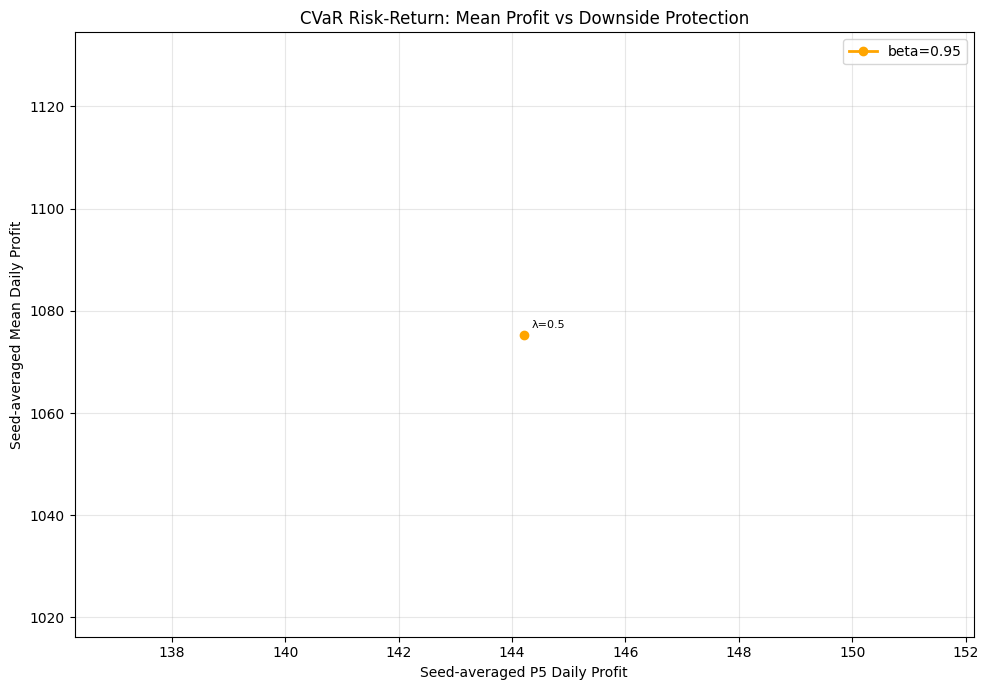

In [24]:
def plot_risk_return_curve_downside(
    summary_df,
    x_col="seed_mean_p5_profit",
    y_col="seed_mean_daily_profit",
    title="CVaR Risk-Return Curve",
):
    plt.figure(figsize=(10, 7))

    betas = sorted(summary_df["beta"].unique())
    colors = {0.90: "blue", 0.95: "orange", 0.99: "green"}

    for beta in betas:
        g = summary_df[summary_df["beta"] == beta].sort_values("lambda")
        plt.plot(
            g[x_col],
            g[y_col],
            marker="o",
            linewidth=2,
            label=f"beta={beta}",
            color=colors.get(beta, None),
        )

        for _, row in g.iterrows():
            plt.annotate(
                f"λ={row['lambda']}",
                (row[x_col], row[y_col]),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8,
            )

    plt.xlabel("Seed-averaged P5 Daily Profit")
    plt.ylabel("Seed-averaged Mean Daily Profit")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_risk_return_curve_downside(
    cvar_final_summary,
    x_col="seed_mean_p5_profit",
    y_col="seed_mean_daily_profit",
    title="CVaR Risk-Return: Mean Profit vs Downside Protection",
)    

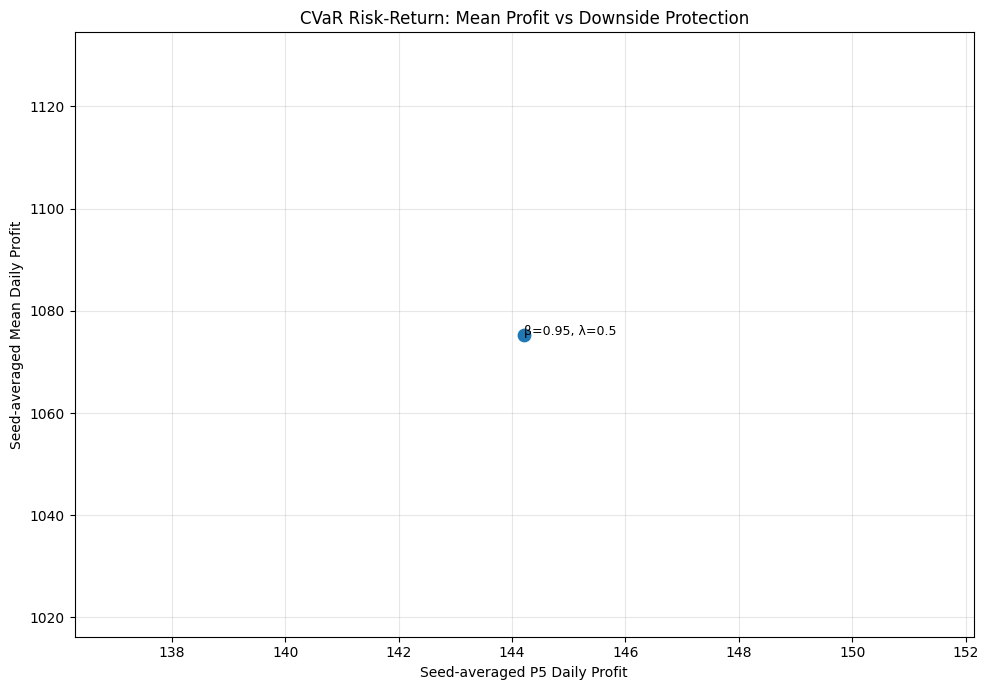

In [25]:
def plot_risk_return_curve_downside(
    summary_df,
    downside_col="seed_mean_p5_profit",
    y_col="seed_mean_daily_profit",
    title="CVaR Risk-Return Curve (Downside)",
):
    plt.figure(figsize=(10, 7))

    for _, row in summary_df.iterrows():
        x = row[downside_col]
        y = row[y_col]
        label = f"β={row['beta']}, λ={row['lambda']}"
        plt.scatter(x, y, s=80)
        plt.text(x, y, label, fontsize=9)

    plt.xlabel("Seed-averaged P5 Daily Profit")
    plt.ylabel("Seed-averaged Mean Daily Profit")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_risk_return_curve_downside(
    cvar_final_summary,
    downside_col="seed_mean_p5_profit",
    y_col="seed_mean_daily_profit",
    title="CVaR Risk-Return: Mean Profit vs Downside Protection",
)

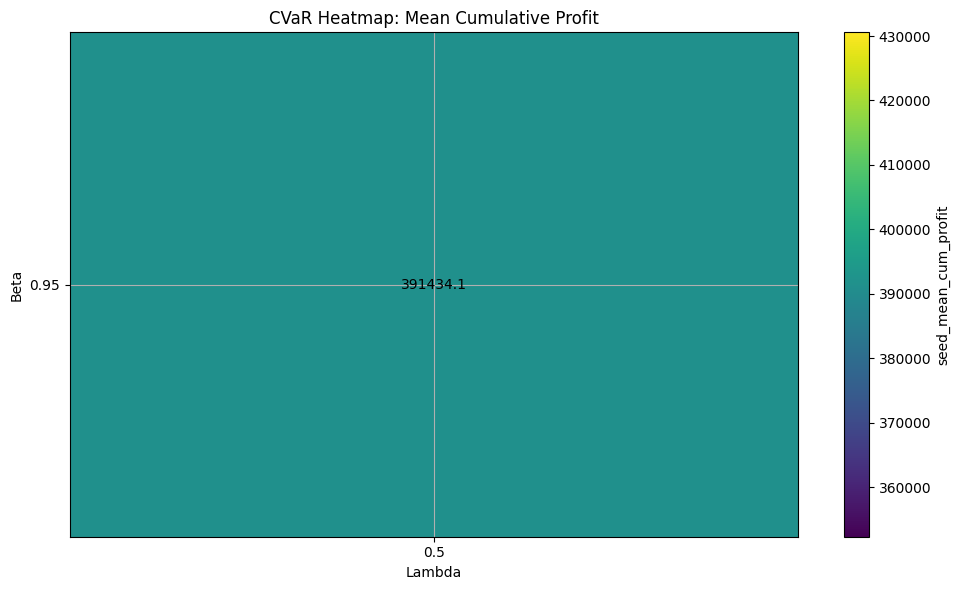

In [26]:
def plot_cvar_heatmap(summary_df, value_col="seed_mean_cum_profit", title="CVaR Heatmap"):
    pivot_df = summary_df.pivot(index="beta", columns="lambda", values=value_col)

    plt.figure(figsize=(10, 6))
    im = plt.imshow(pivot_df.values, aspect="auto")

    plt.xticks(np.arange(len(pivot_df.columns)), pivot_df.columns)
    plt.yticks(np.arange(len(pivot_df.index)), pivot_df.index)

    for i in range(pivot_df.shape[0]):
        for j in range(pivot_df.shape[1]):
            val = pivot_df.iloc[i, j]
            plt.text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=10)

    plt.colorbar(im, label=value_col)
    plt.xlabel("Lambda")
    plt.ylabel("Beta")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_cvar_heatmap(
    cvar_final_summary,
    value_col="seed_mean_cum_profit",
    title="CVaR Heatmap: Mean Cumulative Profit",
)




In [27]:
def plot_cvar_errorbar(summary_df, title="CVaR Mean Cumulative Profit Across Seeds"):
    plt.figure(figsize=(12, 7))

    labels = []
    means = []
    stds = []

    for _, row in summary_df.iterrows():
        labels.append(f"β={row['beta']}, λ={row['lambda']}")
        means.append(row["seed_mean_cum_profit"])
        stds.append(row["seed_std_cum_profit"])

    x = np.arange(len(labels))

    plt.errorbar(x, means, yerr=stds, fmt='o', capsize=5)
    plt.xticks(x, labels, rotation=45, ha="right")
    plt.ylabel("Mean Cumulative Profit")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

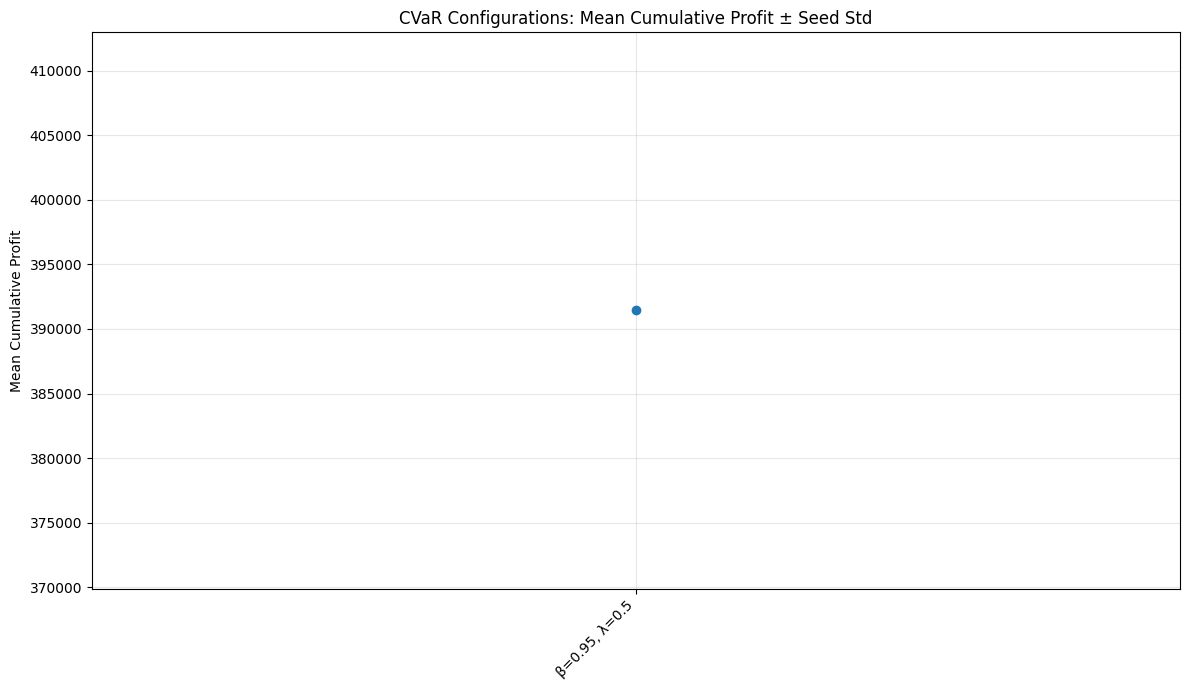

In [28]:
plot_cvar_errorbar(
    cvar_final_summary,
    title="CVaR Configurations: Mean Cumulative Profit ± Seed Std",
)